In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [123]:
df=pd.read_csv('/content/data.csv')

In [124]:
df.head(5)

,Transaction_ID,Date_Time,Branch,Product_Name,Size,Unit_Price,Quantity,Discount_Rate,Topping_Type,Customer_ID,...,Staff_ID,Temperature_Celsius,Humidity_Percent,Store_Rating,Is_Public_Holiday,Category,Region,Is_Weekend,Hour_of_Day,Tax_Amount
0,105526,27/02/2024 13:15,Cairo-Nasr City,Rice Pudding Nuts,Small,48.60,9,0.15,NaN,64440,...,146,21.8,84.2,3.0,0,Traditional,Greater Cairo,0,13,61.24
1,100772,09/01/2024 00:45,Mansoura-Mashaya,Super B.Laban,Medium,54.45,2,0.05,Lotus,52080,...,143,27.7,37.3,1.0,0,Signature,Delta,0,0,15.25
2,107840,22/03/2024 15:45,Alex-Stanly,Om Ali Cream,Large,58.06,7,0.00,Nuts,73849,...,107,33.8,27.7,1.0,1,Traditional,Alexandria,1,15,56.90
3,102396,25/01/2024 22:45,Giza-Zayed,Om Ali Cream,Medium,97.63,6,0.00,NaN,77779,...,117,28.9,61.4,1.0,0,Traditional,Greater Cairo,0,22,82.01
4,101479,16/01/2024 09:30,Tanta-Saeed,Sweet Koshary Mix,Medium,42.94,11,0.15,Lotus,56622,...,128,22.4,37.6,4.0,0,Signature,Delta,0,9,66.13


In [125]:
df.tail(5)

,Transaction_ID,Date_Time,Branch,Product_Name,Size,Unit_Price,Quantity,Discount_Rate,Topping_Type,Customer_ID,...,Staff_ID,Temperature_Celsius,Humidity_Percent,Store_Rating,Is_Public_Holiday,Category,Region,Is_Weekend,Hour_of_Day,Tax_Amount
2995,105735,29/02/2024 17:30,Cairo-Zamalek,Qishtouza Nutella,Medium,76.06,10,0.00,Lotus,89202,...,132,43.0,34.4,NaN,0,Modern,Greater Cairo,0,17,106.48
2996,105192,24/02/2024 01:45,Riyadh-Olaya,Super B.Laban,Small,176.68,8,0.10,Pistachio,85620,...,120,28.1,55.6,2.0,0,Signature,KSA,1,1,197.88
2997,105391,26/02/2024 03:30,Giza-Zayed,Qishtouza Lotus,Small,67.38,11,0.05,Nutella,63862,...,133,39.6,51.1,4.0,0,Modern,Greater Cairo,0,3,103.77
2998,100861,09/01/2024 23:00,Giza-Zayed,Om Ali Cream,Large,78.94,8,0.00,Nutella,70359,...,120,38.0,26.3,5.0,0,Traditional,Greater Cairo,0,23,88.41
2999,107271,16/03/2024 17:30,Cairo-Zamalek,Rice Pudding Nuts,Medium,70.01,8,0.00,NaN,65290,...,136,26.3,30.0,4.0,0,Traditional,Greater Cairo,1,17,78.41


In [126]:
df.shape

(3000, 27)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        3000 non-null   int64  
 1   Date_Time             3000 non-null   object 
 2   Branch                3000 non-null   object 
 3   Product_Name          3000 non-null   object 
 4   Size                  3000 non-null   object 
 5   Unit_Price            3000 non-null   float64
 6   Quantity              3000 non-null   int64  
 7   Discount_Rate         3000 non-null   float64
 8   Topping_Type          2089 non-null   object 
 9   Customer_ID           3000 non-null   int64  
 10  Customer_Age          2620 non-null   float64
 11  Customer_Gender       2658 non-null   object 
 12  Membership_Status     1990 non-null   object 
 13  Payment_Method        3000 non-null   object 
 14  Order_Source          3000 non-null   object 
 15  Delivery_Time_Min    

In [128]:
df.duplicated().sum()

np.int64(0)

In [129]:
df.isnull().sum()

,0
Transaction_ID,0
Date_Time,0
Branch,0
Product_Name,0
Size,0
Unit_Price,0
Quantity,0
Discount_Rate,0
Topping_Type,911
Customer_ID,0


In [130]:
df['Topping_Type']=df['Topping_Type'].fillna('none')

In [131]:
df['Customer_Age']=df['Customer_Age'].fillna(df['Customer_Age'].median())


In [132]:
df['Customer_Gender']=df['Customer_Gender'].fillna(df['Customer_Gender'].mode()[0])

In [133]:
df['Membership_Status'] = df['Membership_Status'].fillna('Unknown')

In [134]:
df['Store_Rating'] = df['Store_Rating'].fillna(
    df['Store_Rating'].median()
)

In [135]:
df.isnull().sum()

,0
Transaction_ID,0
Date_Time,0
Branch,0
Product_Name,0
Size,0
Unit_Price,0
Quantity,0
Discount_Rate,0
Topping_Type,0
Customer_ID,0


In [136]:
df['Date_Time']=pd.to_datetime(df['Date_Time'])

/tmp/ipykernel_2517/3691071797.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date_Time']=pd.to_datetime(df['Date_Time'])


In [137]:
df.describe()

,Transaction_ID,Date_Time,Unit_Price,Quantity,Discount_Rate,Customer_ID,Customer_Age,Delivery_Time_Min,Delivery_Distance_KM,Staff_ID,Temperature_Celsius,Humidity_Percent,Store_Rating,Is_Public_Holiday,Is_Weekend,Hour_of_Day,Tax_Amount
count,3000.000000,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,105090.038000,2024-02-23 00:15:34.200000256,156.376520,6.065333,0.028967,70136.722667,43.877000,64.119333,7.710367,124.689667,29.860767,54.910200,2.936333,0.048333,0.428000,11.679667,94.090617
min,100002.000000,2024-01-01 00:15:00,40.020000,-5.000000,0.000000,50001.000000,12.000000,10.000000,0.500000,101.000000,15.000000,20.000000,1.000000,0.000000,0.000000,0.000000,5.600000
25%,102547.750000,2024-01-27 12:41:15,76.422500,3.000000,0.000000,60318.000000,30.000000,36.000000,4.000000,113.000000,22.300000,37.500000,2.000000,0.000000,0.000000,6.000000,44.337500
50%,105174.000000,2024-02-23 21:15:00,111.030000,6.000000,0.000000,70376.000000,43.500000,64.000000,7.700000,124.000000,29.700000,55.100000,3.000000,0.000000,0.000000,12.000000,81.190000
75%,107570.250000,2024-03-19 20:18:45,144.622500,9.000000,0.050000,80102.500000,57.000000,92.000000,11.400000,137.000000,37.600000,71.725000,4.000000,0.000000,1.000000,18.000000,134.372500
max,109998.000000,2024-04-14 03:15:00,9999.990000,11.000000,0.150000,89993.000000,280.000000,119.000000,15.000000,149.000000,45.000000,90.000000,5.000000,1.000000,1.000000,23.000000,276.540000
std,2894.939121,NaN,675.304637,3.229119,0.050482,11539.556198,20.856187,31.737121,4.197795,14.107671,8.729210,20.034282,1.327981,0.214505,0.494871,6.919852,62.402832


<Axes: >

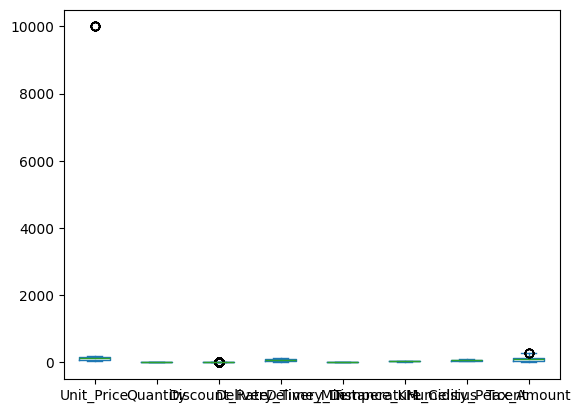

In [138]:
df[['Unit_Price','Quantity','Discount_Rate','Delivery_Time_Min','Delivery_Distance_KM','Temperature_Celsius',
   'Humidity_Percent','Tax_Amount'
]].plot(kind='box')


In [139]:
cols=['Unit_Price','Quantity','Discount_Rate','Delivery_Time_Min','Delivery_Distance_KM','Temperature_Celsius',
   'Humidity_Percent','Tax_Amount']
for col in cols:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  IQR=q3-q1
  lower=q1-1.5*IQR
  upper=q3+1.5*IQR
  outlaiers=((df[col]<lower)|(df[col]>upper)).sum()
  print(col , " : " ,outlaiers )

Unit_Price  :  14
Quantity  :  0
Discount_Rate  :  291
Delivery_Time_Min  :  0
Delivery_Distance_KM  :  0
Temperature_Celsius  :  0
Humidity_Percent  :  0
Tax_Amount  :  9


In [140]:
Total_branch=df['Branch'].nunique()
print(" Total_branch ",Total_branch)

 Total_branch  8


In [141]:
Total_quantity=df['Quantity'].sum()
print(" Total_quantity ",Total_quantity)

 Total_quantity  18196


In [142]:
df['Total_Revenue'] = df['Unit_Price'] * df['Quantity'] +df['Tax_Amount']
total_revenue = df['Total_Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 3109178.2399999998


In [143]:
Total_Customer=df['Customer_ID'].nunique()
print(" Total_Customer ",Total_Customer)

 Total_Customer  2903


In [144]:
AVG_discount=df['Discount_Rate'].mean()*100
print(" AVG_discount ",AVG_discount)

 AVG_discount  2.896666666666667


In [145]:
AVG_Customer_Age=df['Customer_Age'].mean()
print(" AVG_Customer_Age ",AVG_Customer_Age)

 AVG_Customer_Age  43.877


In [146]:
AVG_Delivery=df['Delivery_Time_Min'].mean()
print(" AVG_Delivery ",AVG_Delivery)


 AVG_Delivery  64.11933333333333


In [147]:
AVG_rate=df['Store_Rating'].mean()
print(" AVG_rate ",AVG_rate)

 AVG_rate  2.9363333333333332


In [148]:
AVG_Delivery_Distance=df['Delivery_Distance_KM'].mean()
print(" AVG_Delivery_Distance ",AVG_Delivery_Distance)


 AVG_Delivery_Distance  7.710366666666666


In [149]:
df['Year']=df['Date_Time'].dt.year

In [150]:
df['month']=df['Date_Time'].dt.month

In [151]:
df['day']=df['Date_Time'].dt.day

In [152]:
def get_shift(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Late Night'

df['Shift'] = df['Hour_of_Day'].apply(get_shift)

# **Sales analysis**

In [153]:
branch_revenue=(df.groupby('Branch')['Total_Revenue'].sum().sort_values(ascending=False).to_frame('Total_Revenue')
)
branch_revenue.head(5)

,Total_Revenue
Branch,
Cairo-Nasr City,680341.29
Dubai-Marina,462245.08
Tanta-Saeed,401334.17
Mansoura-Mashaya,389019.47
Cairo-Zamalek,324001.64


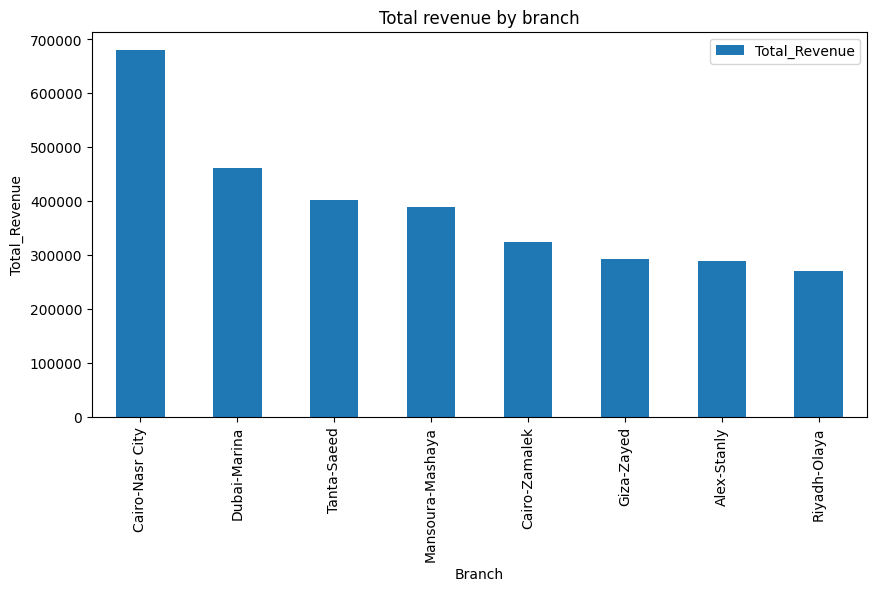

In [154]:
branch_revenue.plot(
    kind='bar',figsize=((10,5))
)
plt.title('Total revenue by branch')
plt.xlabel('Branch')
plt.ylabel('Total_Revenue')
plt.show()

In [155]:
product_revenue=df.groupby('Product_Name')['Total_Revenue'].sum().sort_values(ascending=False).to_frame('Total_Revenue')
product_revenue.head(5)

,Total_Revenue
Product_Name,
Qishtouza Nutella,551211.23
Rice Pudding Oven,406460.65
Super B.Laban,395195.50
Rice Pudding Nuts,393381.89
Qishtouza Lotus,377579.25


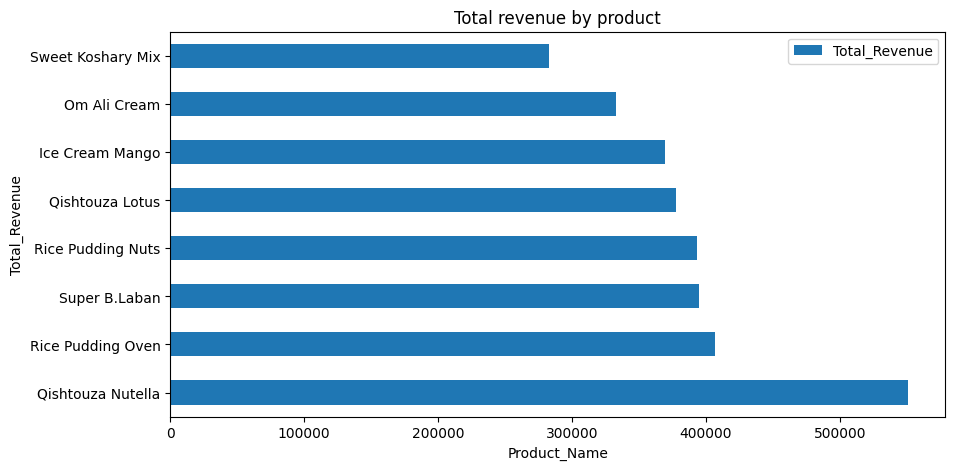

In [156]:
product_revenue.plot(
    kind='barh',figsize=((10,5))
)
plt.title('Total revenue by product')
plt.xlabel('Product_Name')
plt.ylabel('Total_Revenue')
plt.show()

In [157]:
Order_Source_revenue=(df.groupby('Order_Source')['Total_Revenue'].sum().sort_values(ascending=False).to_frame('Total_Revenue')
)
Order_Source_revenue.head()

,Total_Revenue
Order_Source,
ElMenus,1001298.04
Talabat,768109.43
In-store,679489.55
Mobile App,660281.22


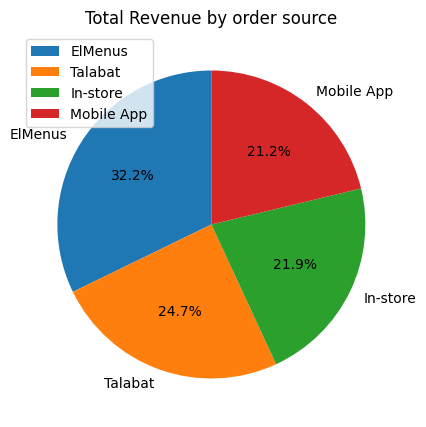

In [158]:
Order_Source_revenue.plot(
    kind='pie',
    y='Total_Revenue',
    figsize=(10, 5),
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Total Revenue by order source')
plt.ylabel('')
plt.show()

In [159]:
Category_revenue=(df.groupby('Category')['Total_Revenue'].sum().sort_values(ascending=False).to_frame('Total_Revenue')
)
Category_revenue.head()

,Total_Revenue
Category,
Traditional,1132604.01
Modern,928790.48
Signature,678318.47
Ice Cream,369465.28


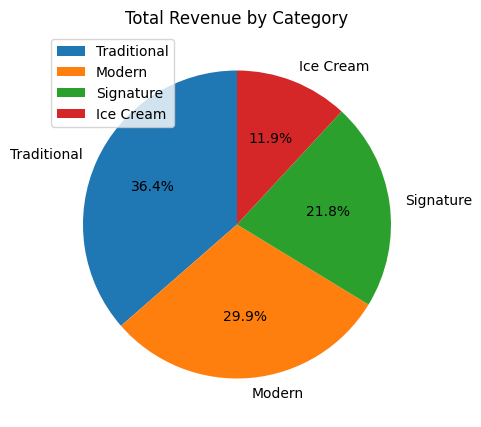

In [160]:
Category_revenue.plot(
    kind='pie',
    y='Total_Revenue',
    figsize=(10, 5),
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Total Revenue by Category')
plt.ylabel('')
plt.show()

In [161]:
Region_revenue=(df.groupby('Region')['Total_Revenue'].sum().sort_values(ascending=False).to_frame('Total_Revenue')
)
Region_revenue.head()

,Total_Revenue
Region,
Greater Cairo,1296654.59
Delta,790353.64
UAE,462245.08
Alexandria,289502.11
KSA,270422.82


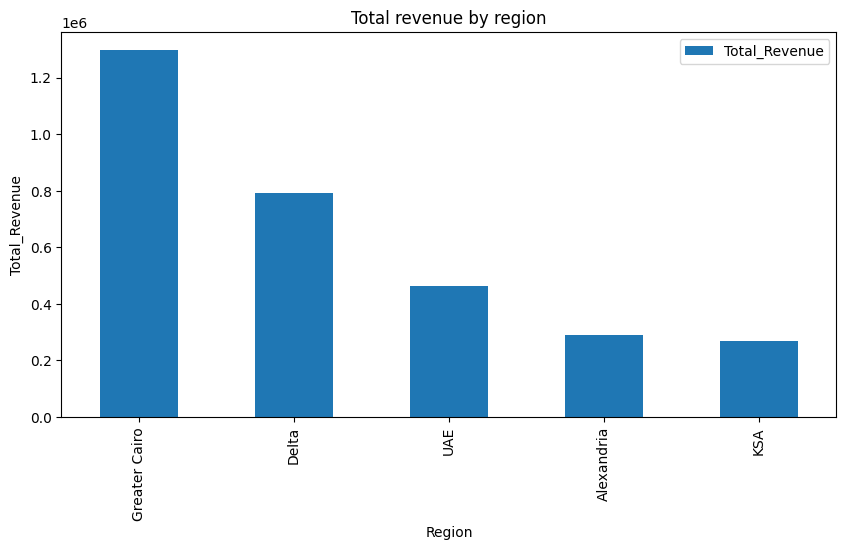

In [162]:
Region_revenue.plot(
    kind='bar',figsize=((10,5))
)
plt.title('Total revenue by region')
plt.xlabel('Region')
plt.ylabel('Total_Revenue')
plt.show()

In [163]:
month_revenue=(df.groupby('month')['Total_Revenue'].sum().sort_values(ascending=False).to_frame('Total_Revenue')
)
month_revenue.head()

,Total_Revenue
month,
1,1032694.93
3,935084.25
2,848489.27
4,292909.79


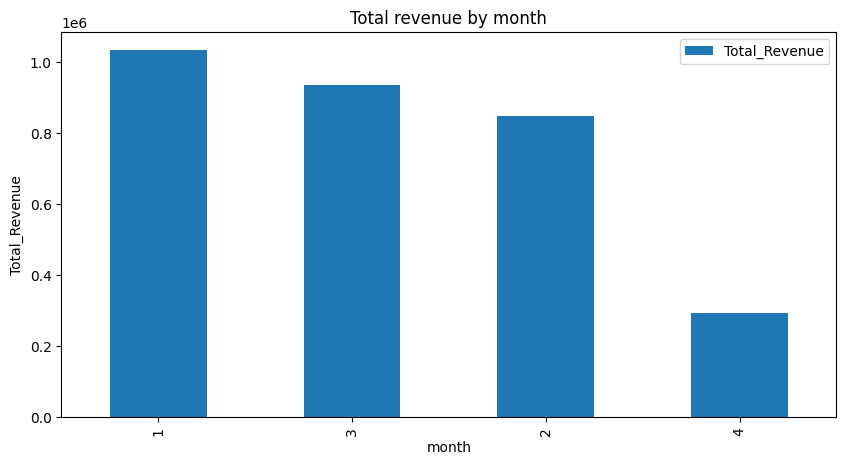

In [164]:
month_revenue.plot(
    kind='bar',figsize=((10,5))
)
plt.title('Total revenue by month')
plt.xlabel('month')
plt.ylabel('Total_Revenue')
plt.show()

In [165]:
Shift_revenue=(df.groupby('Shift')['Total_Revenue'].sum().sort_values(ascending=False).to_frame('Total_Revenue')
)
Shift_revenue.head()

,Total_Revenue
Shift,
Morning,1128152.66
Late Night,841340.44
Evening,595499.65
Afternoon,544185.49


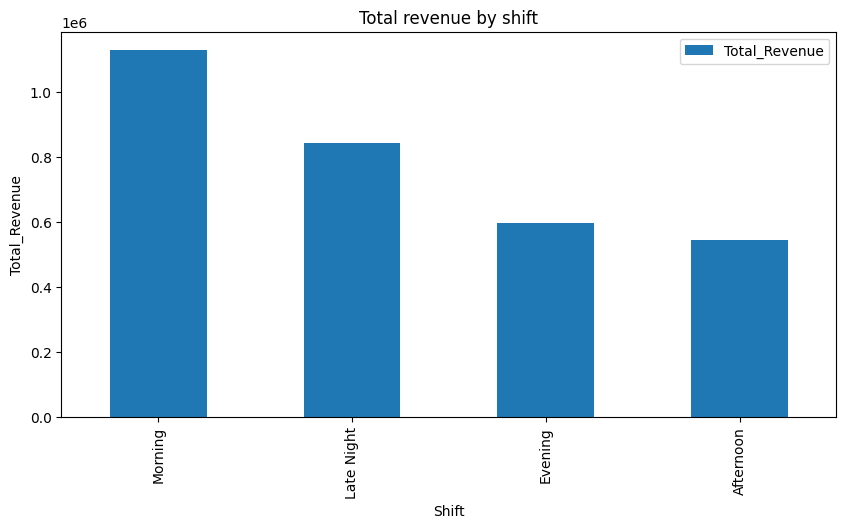

In [166]:
Shift_revenue.plot(
    kind='bar',figsize=((10,5))
)
plt.title('Total revenue by shift')
plt.xlabel('Shift')
plt.ylabel('Total_Revenue')
plt.show()

In [167]:
size_quantity=(df.groupby('Size')['Quantity'].sum().sort_values(ascending=False).to_frame('Total_quantity')
)
size_quantity.head()

,Total_quantity
Size,
Medium,9148
Large,5531
Small,3517


# **ٌRating**

In [168]:
top_5_stores = (
    df.groupby('Branch')['Store_Rating']
      .mean()
      .sort_values(ascending=False)
      .head(5)
      .to_frame('Average Rating')
      .reset_index()
)

top_5_stores

,Branch,Average Rating
0,Cairo-Zamalek,3.080214
1,Giza-Zayed,2.975543
2,Riyadh-Olaya,2.969188
3,Dubai-Marina,2.957895
4,Mansoura-Mashaya,2.924870


# **discount**

In [169]:
category_discount = (
    df.groupby('Category')['Discount_Rate']
      .mean().mul(100)
      .sort_values(ascending=False)
)

category_discount

,Discount_Rate
Category,
Modern,3.211436
Ice Cream,2.876543
Traditional,2.848214
Signature,2.655602


In [170]:
product_discount = (
    df.groupby('Product_Name')['Discount_Rate']
      .mean().mul(100)
      .sort_values(ascending=False)
      .head(10)
)

product_discount

,Discount_Rate
Product_Name,
Qishtouza Lotus,3.220779
Qishtouza Nutella,3.201635
Om Ali Cream,2.971204
Ice Cream Mango,2.876543
Rice Pudding Oven,2.837466
Rice Pudding Nuts,2.733333
Super B.Laban,2.662890
Sweet Koshary Mix,2.648649


In [171]:
branch_discount = (
    df.groupby('Branch')['Discount_Rate']
      .mean().mul(100)
      .sort_values(ascending=False)
      .head(10)
)

branch_discount

,Discount_Rate
Branch,
Alex-Stanly,3.175853
Riyadh-Olaya,2.997199
Cairo-Nasr City,2.888283
Mansoura-Mashaya,2.875648
Tanta-Saeed,2.829457
Giza-Zayed,2.812500
Cairo-Zamalek,2.807487
Dubai-Marina,2.789474


In [172]:
def discount_group(x):
    if x == 0:
        return 'No Discount'
    elif x <= 0.05:
        return 'Low Discount'
    elif x <= 0.15:
        return 'Medium Discount'
    else:
        return 'High Discount'

df['Discount_Group'] = df['Discount_Rate'].apply(discount_group)

In [173]:
discount_analysis = (
    df.groupby('Discount_Group')
      .agg(
          Total_Quantity=('Quantity', 'sum'),
          Avg_Quantity=('Quantity', 'mean'),
          Orders=('Transaction_ID', 'count')
      )
      .sort_values('Total_Quantity', ascending=False)
)

discount_analysis

,Total_Quantity,Avg_Quantity,Orders
Discount_Group,,,
No Discount,13023,6.102624,2134
Medium Discount,3460,5.955250,581
Low Discount,1713,6.010526,285


In [174]:
discount_revenue = (
    df.groupby('Discount_Group')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
)

discount_revenue

,Total_Revenue
Discount_Group,
No Discount,2069449.67
Medium Discount,757842.69
Low Discount,281885.88


In [175]:
membership_discount = (
    df.groupby('Membership_Status')['Discount_Rate']
      .mean().mul(100)
      .sort_values(ascending=False)
)

membership_discount

,Discount_Rate
Membership_Status,
Bronze,3.183206
Unknown,2.955446
Silver,2.720588
Gold,2.702290


In [176]:
Count_Is_Weekend=df['Is_Weekend'].value_counts()
print(Count_Is_Weekend)

Is_Weekend
0    1716
1    1284
Name: count, dtype: int64


In [177]:
Is_Weekend_revenue = (
    df.groupby('Is_Weekend')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
)

Is_Weekend_revenue

,Total_Revenue
Is_Weekend,
0,1891404.63
1,1217773.61


In [178]:
Count_Is_Public_Holiday=df['Is_Public_Holiday'].value_counts()
print(Count_Is_Public_Holiday)

Is_Public_Holiday
0    2855
1     145
Name: count, dtype: int64


In [179]:
Is_Public_Holiday_revenue = (
    df.groupby('Is_Public_Holiday')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
)

Is_Public_Holiday_revenue

,Total_Revenue
Is_Public_Holiday,
0,2903627.90
1,205550.34


In [180]:
df['Temperature_Celsius'].mean()

np.float64(29.860766666666667)

In [181]:
df['Humidity_Percent'].mean()

np.float64(54.9102)

In [182]:
def temp_group(x):
    if x < 20:
        return 'Cold'
    elif x < 25:
        return 'Moderate'
    else:
        return 'Hot'

df['Temperature_Group'] = df['Temperature_Celsius'].apply(temp_group)

In [183]:
temperature_revenue = (
    df.groupby('Temperature_Group')['Total_Revenue']
      .sum()
      .sort_values(ascending=False)
)

temperature_revenue

,Total_Revenue
Temperature_Group,
Hot,1864255.54
Moderate,657013.75
Cold,587908.95


In [184]:
temperature_sales = (
    df.groupby('Temperature_Group')['Quantity']
      .sum()
      .sort_values(ascending=False)
)
temperature_sales

,Quantity
Temperature_Group,
Hot,11908
Cold,3164
Moderate,3124


In [185]:
temperature_delivery = (
    df.groupby('Temperature_Group')['Delivery_Time_Min']
      .mean()
      .sort_values(ascending=False)
)
temperature_delivery

,Delivery_Time_Min
Temperature_Group,
Hot,64.542278
Moderate,63.359127
Cold,63.251440


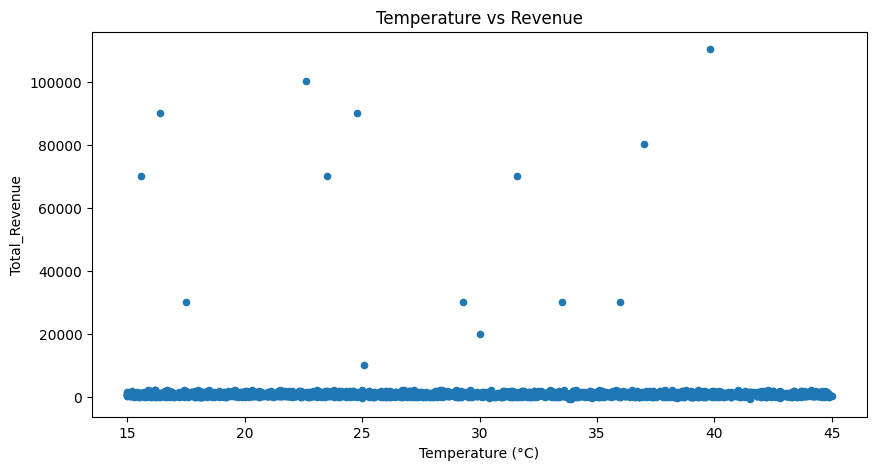

In [186]:
df.plot(
    kind='scatter',
    x='Temperature_Celsius',
    y='Total_Revenue',
    figsize=(10,5)
)

plt.title('Temperature vs Revenue')
plt.xlabel('Temperature (°C)')
plt.ylabel('Total_Revenue')
plt.show()

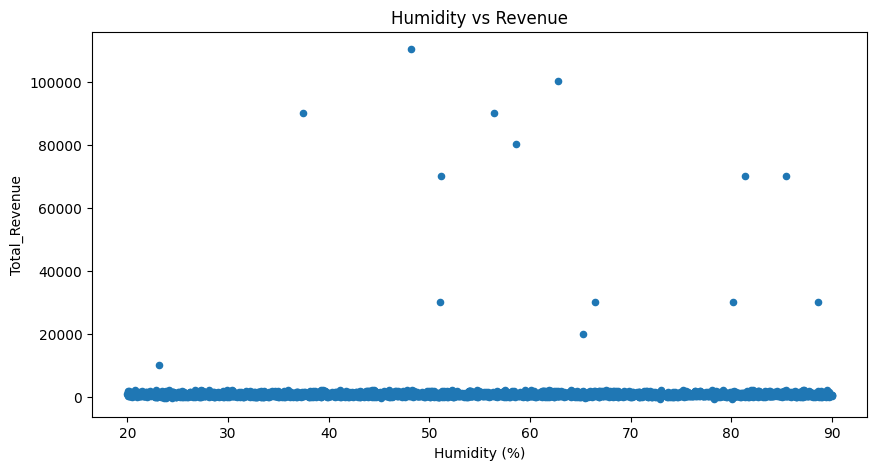

In [187]:
df.plot(
    kind='scatter',
    x='Humidity_Percent',
    y='Total_Revenue',
    figsize=(10,5)
)

plt.title('Humidity vs Revenue')
plt.xlabel('Humidity (%)')
plt.ylabel('Total_Revenue')
plt.show()

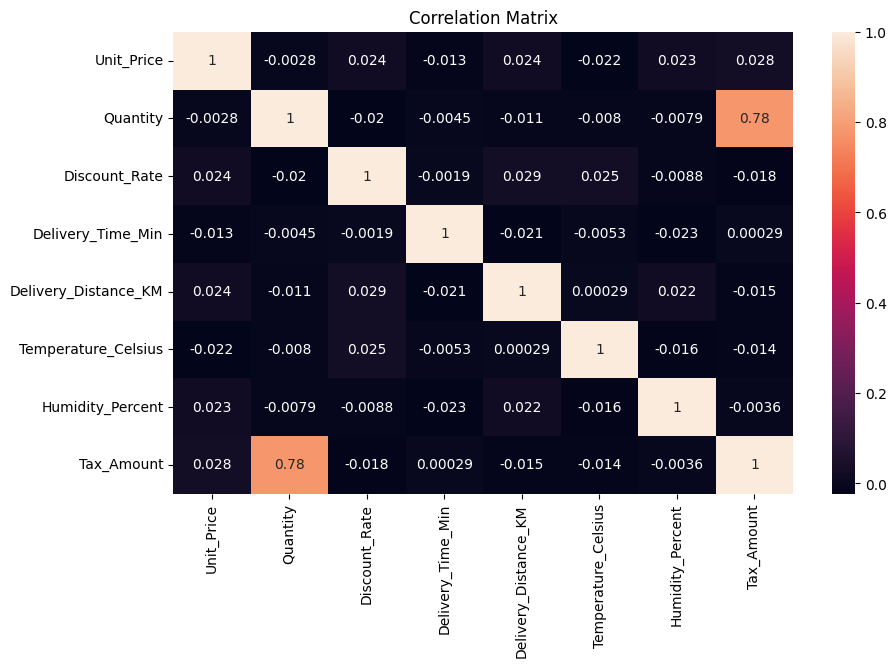

In [188]:
correlation_matrix = df[
    [
 'Unit_Price','Quantity','Discount_Rate','Delivery_Time_Min','Delivery_Distance_KM','Temperature_Celsius',
   'Humidity_Percent','Tax_Amount'
    ]
].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title('Correlation Matrix')

plt.show()

In [189]:
df.to_csv('/content/final_dataset.csv', index=False)

In [190]:
from google.colab import files
files.download('/content/final_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>